In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import seaborn as sns
import matplotlib.gridspec as gridspec
import ast
import sys
sys.path.append('../no_degeneracy/')
sys.path.append('../no_degeneracy/Prior/')
from mcmc import *
from parallel import *
from fit_prior import read_prior_par
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error

#Colors
#----------------------------------------------
colors_june={'0.5x':['#fee0d2', '#deebf7'],
       '1x':['#fc9272', '#9ecae1'],
       '2x':['#de2d26', '#3182bd'] }

color_noise=sns.color_palette("colorblind")[5]
color_data='#636363'
color_bms=colors_june['2x'][1]
color_ann=colors_june['2x'][0]
#-----------------------------------------------

In [2]:
#Read NN and BMS data
n=10; #1,5,7,8,10
sigma=0.0
realization=0

NPAR=10 #10, 20
steps=50000

file_model='NN_no_overfit_sigma_' + str(sigma) + '_r_' + str(realization) + '.csv'
model_d='../../data/nns/nguyen/approximation/'+ file_model

d=pd.read_csv(model_d)
dn=d[d['rep']==n]
dn.set_index('Unnamed: 0', inplace=True)
dn.index.name = None
dn=dn.reset_index(drop=True)
display(dn)

#Read BMS trace
filename='BMS_nguyen_n_' + str(n)+'_sigma_'+str(sigma)+ '_r_' + str(realization) + '_id_0_trace_'+str(steps)+'_prior_'+str(NPAR)+ '.csv'
trace=pd.read_csv('../../data/MSTraces/nguyen/' + filename, sep=';', header=None, names=['t', 'H', 'expr', 'parvals', 'kk1', 'kk2','kk3'])

,x,y,z,rep,noise,z_noise,zmodel
0,0.0000,0.0000,0.000000,10,0.0,0.000000,-0.015948
1,0.0125,0.0125,0.018749,10,0.0,0.018749,0.006646
2,0.0250,0.0250,0.037488,10,0.0,0.037488,0.028870
3,0.0375,0.0375,0.056210,10,0.0,0.056210,0.050728
4,0.0500,0.0500,0.074906,10,0.0,0.074906,0.072225
...,...,...,...,...,...,...,...
75,0.9375,0.9375,0.880083,10,0.0,0.880083,0.990928
76,0.9500,0.9500,0.879858,10,0.0,0.879858,0.998959
77,0.9625,0.9625,0.879273,10,0.0,0.879273,1.006924
78,0.9750,0.9750,0.878331,10,0.0,0.878331,1.014825


In [3]:
#Parameters to read models
VARS = ['x',]
x = dn[[c for c in VARS]].copy()


if NPAR==10:
    prior_par = read_prior_par('../no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np10.2017-10-18 18:07:35.089658.dat')
elif NPAR==20:
    prior_par = read_prior_par('../no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np20.maxs200.2024-05-10 162907.551306.dat')

In [4]:
#Minimum description length model
y=dn.z_noise

minrow = trace[trace.H == min(trace.H)].iloc[0]
minH, minexpr, minparvals = minrow.H, minrow.expr, ast.literal_eval(minrow.parvals)

t = Tree(
    variables=list(x.columns),
    parameters=['a%d' % i for i in range(NPAR)],
    x=x, y=y,
    prior_par=prior_par,
    max_size=200,
    from_string=minexpr,
)

t.set_par_values(deepcopy(minparvals))

<lambdifygenerated-7>:2: RuntimeWarning: invalid value encountered in divide
  return (x**2 + x)/x
<lambdifygenerated-8>:2: RuntimeWarning: invalid value encountered in divide
  return (x**2 + x)/x
<lambdifygenerated-9>:2: RuntimeWarning: invalid value encountered in divide
  return (x*sin(x) + x)/x
<lambdifygenerated-10>:2: RuntimeWarning: invalid value encountered in divide
  return (x*sin(x) + x)/x
<lambdifygenerated-11>:2: RuntimeWarning: invalid value encountered in divide
  return (x*sin(x**2) + x)/x
<lambdifygenerated-12>:2: RuntimeWarning: invalid value encountered in divide
  return (x*sin(x**2) + x)/x
<lambdifygenerated-13>:2: RuntimeWarning: invalid value encountered in divide
  return (x*sin(x**2) + x)/x
<lambdifygenerated-14>:2: RuntimeWarning: invalid value encountered in divide
  return (x*sin(x**2) + x)/x
<lambdifygenerated-15>:2: RuntimeWarning: invalid value encountered in divide
  return (x*sin(_a6_*x) + x)/x
/export/home/shared/Projects/ANN/Sergio/BMS_approximator/b

In [5]:
display(t)
display(t.par_values)

(((sin((x * _a6_)) * _a4_) + (_a5_ * (_a6_ * sin(x)))) / (_a4_ * _a6_))

{'d0': {'_a4_': 1.1655611943983897,
  '_a5_': 0.582780597199195,
  '_a6_': 2.0000000000000004,
  '_a0_': 1.0,
  '_a1_': 1.0,
  '_a2_': 1.0,
  '_a3_': 1.0,
  '_a7_': 1.0}}

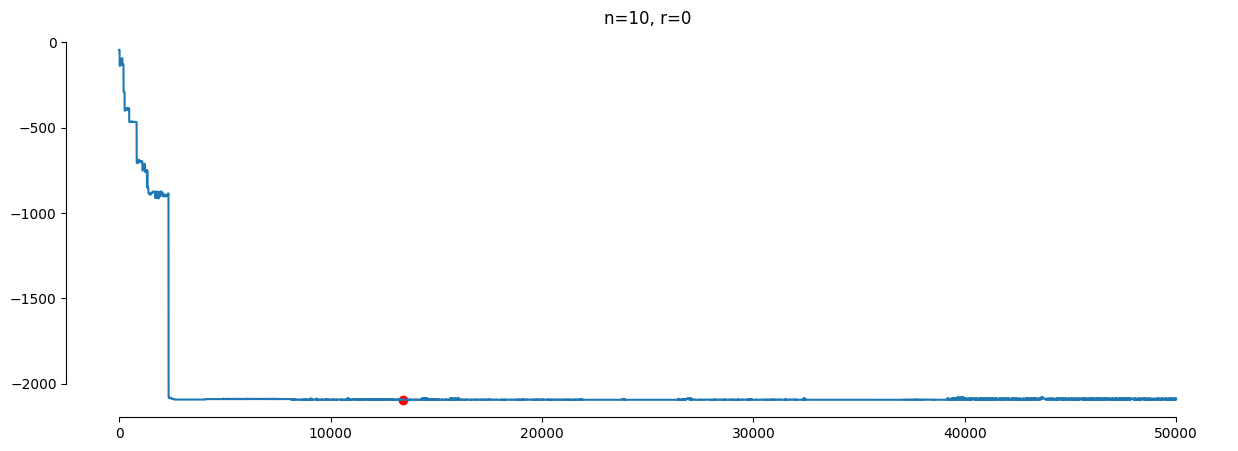

In [6]:
Nini = 00
plt.figure(figsize=(15, 5))

#Define figure size in cm                                                                           
Extensions=['.png']

#Fonts and sizes                                                                                    
size_axis=7;size_ticks=6;size_title=5
line_w=1;marker_s=3 #width and marker size                                                           
plt.title( 'n=' + str(n) +', r=' + str(realization))
plt.plot(trace.t[trace.t > Nini], trace.H[trace.t > Nini])
plt.scatter(minrow['t'], minH,color='r')
sns.despine(trim=True)

#Name_figure='Energy_' + function + '_n_' + str(n) + '_sigma_' + str(sigma) + '_r_'  + str(realization) + '_par_' + str(NPAR)

#for ext in Extensions:
#        plt.savefig('../results/' + Name_figure + ext,dpi=300)

 
plt.show()

80
60
0.7375


,x,y,z,rep,noise,z_noise,zmodel,ybms
0,0.0000,0.0000,0.000000,10,0.0,0.000000,-0.015948,0.000000
1,0.0125,0.0125,0.018749,10,0.0,0.018749,0.006646,0.018749
2,0.0250,0.0250,0.037488,10,0.0,0.037488,0.028870,0.037488
3,0.0375,0.0375,0.056210,10,0.0,0.056210,0.050728,0.056210
4,0.0500,0.0500,0.074906,10,0.0,0.074906,0.072225,0.074906
...,...,...,...,...,...,...,...,...
75,0.9375,0.9375,0.880083,10,0.0,0.880083,0.990928,0.880083
76,0.9500,0.9500,0.879858,10,0.0,0.879858,0.998959,0.879858
77,0.9625,0.9625,0.879273,10,0.0,0.879273,1.006924,0.879273
78,0.9750,0.9750,0.878331,10,0.0,0.878331,1.014825,0.878331


<Figure size 1181.1x944.882 with 0 Axes>

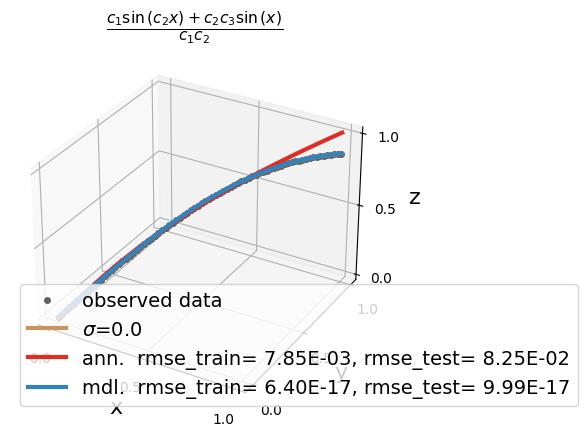

(((sin((x * _a6_)) * _a4_) + (_a5_ * (_a6_ * sin(x)))) / (_a4_ * _a6_)) {'d0': {'_a4_': 1.1655611943983897, '_a5_': 0.582780597199195, '_a6_': 2.0000000000000004, '_a0_': 1.0, '_a1_': 1.0, '_a2_': 1.0, '_a3_': 1.0, '_a7_': 1.0}}


In [10]:
#Validation and train borders
n_points=int(len(dn.index))
print(n_points)
train_fraction=5/8;valid_fraction=1/8;test_fraction=0.2
train_size_ann=int(n_points*train_fraction)
train_size_bms=train_size_ann + int(n_points*valid_fraction)

train_border=dn.loc[train_size_bms-1]['x']
print(train_size_bms)
print(train_border)

dplot = deepcopy(dn)

dplot['ybms'] = t.predict(x)
display(dplot)

#display(dplot.loc[train_size-1:])

rmse_nn_train=root_mean_squared_error(dplot.loc[:train_size_bms-1]['zmodel'],dplot.loc[:train_size_bms -1]['z'])
rmse_nn_test=root_mean_squared_error(dplot.loc[train_size_bms-1:]['zmodel'],dplot.loc[train_size_bms -1:]['z'])
rmse_mdl_train=root_mean_squared_error(dplot.loc[:train_size_bms-1]['ybms'],dn.loc[:train_size_bms-1]['z'])
rmse_mdl_test =root_mean_squared_error(dplot.loc[train_size_bms-1:]['ybms'],dn.loc[train_size_bms-1:]['z'])

 
#Define figure size in cm                                                                           
cm = 1/2.54 #convert inch to cm                                                                     
width = 10*cm; height=8*cm

Extensions=['.png']  
#Text and figure sizes  
#--------------------------------
size_axis=16;size_ticks=14;size_title=16
line_w=3;marker_s=8
#--------------------------------

#ticks, limits and titles
#--------------------------------------------------------------------------------------------
ticks={1:{'x':[0, 0.5, 1], 'y':[ -3, 0, 3, 6.0]}, 5:{'x':[-1, 0, 1], 'y':[-0.75,-0.5, -0.25]}, 
       7:{'x':[0,1,2,], 'y': [1,2,3]}, 8:{'x':[0,2,4], 'y':[0, 1, 2]}, 
       10:{'x':[0,0.5,1], 'y':[0,0.5,1], 'z':[0,0.5,1] } }

limits={1:{'x':[-1.1,1.1], 'y':[-3.25, 8]}, 5:{'x':[-1.2,1.2], 'y':[-0.8,-0.2]}, 
        7:{'x':[-0.1,2.1], 'y': [0.4,3.1]}, 8:{'x':[-0.1,4.2], 'y':[-0.1, 2.5]}, 
        10:{'x':[-0.1,1.1], 'y':[-0.1,1.1], 'z':[-0.1,1.1] } } 

#nguyen title dict
titles={1: r'$y_1=3.39 x^3 + 2.12 x^2 +1.78x$',
        5: r'$y_5=\sin(x^2) \cos(x)$', 
        7: r'$y_7=\log(x+1.4) + \log(x^2 + 1.3)$',
        8: r'$y_8=\sqrt{1.23x}$',
        10:r'$y_{10}=\sin(1.5x) \cos(0.5y)$' }
#--------------------------------------------------------------------------------------------

fig=figure(figsize=(width,height), dpi=300)    

if n==10:
    ax = plt.figure().add_subplot(projection='3d')
    ax.plot(dn.x, dn.y, dn.z, '.', markersize=marker_s, color=color_data, label='observed data')
    ax.plot(dn.x, dn.y, dn.z_noise, linewidth=line_w,color=color_noise, label=r'$\sigma$='+str(sigma))
    ax.plot(dn.x, dn.y, dn.zmodel,linewidth=line_w, color=color_ann, label='ann.  rmse_train= %.2E, rmse_test= %.2E' % ( rmse_nn_train, rmse_nn_test)) 
    ax.plot(dplot.x, dplot.y, dplot.ybms, linewidth=line_w,color=color_bms,label='mdl.  rmse_train= %.2E, rmse_test= %.2E' % ( rmse_mdl_train, rmse_mdl_test))
    ax.set_xticks(ticks[n]['x']);ax.set_yticks(ticks[n]['y']);ax.set_zticks(ticks[n]['z'])
    ax.set_xlabel('x',fontsize=size_axis);ax.set_ylabel('y',fontsize=size_axis);ax.set_zlabel('z',fontsize=size_axis)

else:
    plt.plot(dn['x'], dn['z'],'.', markersize=marker_s, color=color_data, label='observed data')
    plt.plot(dn['x'], dn['zmodel'],linewidth=line_w, color=color_ann, label='ann.  rmse_train= %.2E, rmse_test= %.2E' % ( rmse_nn_train, rmse_nn_test)) 
    plt.plot(dplot.x, dplot.ybms, linewidth=line_w,color=color_bms,label='mdl.  rmse_train= %.2E, rmse_test= %.2E' % ( rmse_mdl_train, rmse_mdl_test))
    plt.plot(dn['x'], dn['z_noise'],linewidth=line_w, markersize=marker_s, color=color_noise,label=r'$\sigma$='+str(sigma)) 

    train_size=60
    train_border=dn.loc[train_size-1]['x']
    plt.axvline(x=train_border,linestyle='--',linewidth=line_w, color='k')
    plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
    plt.xticks(ticks[n]['x'], fontsize=size_ticks);plt.yticks(ticks[n]['y'], fontsize=size_ticks)
    plt.xlim(limits[n]['x'][0], limits[n]['x'][1]);plt.ylim(limits[n]['y'][0], limits[n]['y'][1])
    

plt.legend(loc='best', fontsize=size_ticks)
plt.title('$%s$' % t.latex(),fontsize=size_title)
    
Name_figure='prediction_'  + 'nguyen_n_' + str(n) + '_sigma_' + str(sigma) + '_r_'  + str(realization) + '_par_' + str(NPAR)
    
for ext in Extensions:
        plt.savefig('../../results/' + Name_figure +ext,dpi=300)

plt.show()

print(t,t.par_values)

In [ ]:
t.par_values


In [ ]:
print(len(t.par_values['d0']))

a0=t.par_values['d0']['_a0_']
a1=t.par_values['d0']['_a1_']
a2=t.par_values['d0']['_a2_']
a3=t.par_values['d0']['_a3_']
a4=t.par_values['d0']['_a4_']
a5=t.par_values['d0']['_a5_']
a6=t.par_values['d0']['_a6_']
a7=t.par_values['d0']['_a7_']
print(a1, a2, a3)
    